# Iris Classification using Decision Tree (Optimized Approach)

## Problem Statement
Build a machine learning model that can classify iris flowers into different species based on their physical measurements.

---

## Goals
- Construct a Decision Tree classifier
- Interpret model decisions visually
- Control overfitting using pruning
- Measure performance using evaluation metrics


In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [14]:
data = pd.read_csv("iris.csv")

data.columns = [col.lower().replace(" ", "_") for col in data.columns]

data.sample(5)

,sepal_length,sepal_width,petal_length,petal_width,species
145,6.7,3.0,5.2,2.3,virginica
136,6.3,3.4,5.6,2.4,virginica
52,6.9,3.1,4.9,1.5,versicolor
121,5.6,2.8,4.9,2.0,virginica
74,6.4,2.9,4.3,1.3,versicolor


In [3]:
print("Shape:", data.shape)
print("\nColumns:", data.columns.tolist())

data.describe()

Shape: (150, 5)

Columns: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## Class Distribution

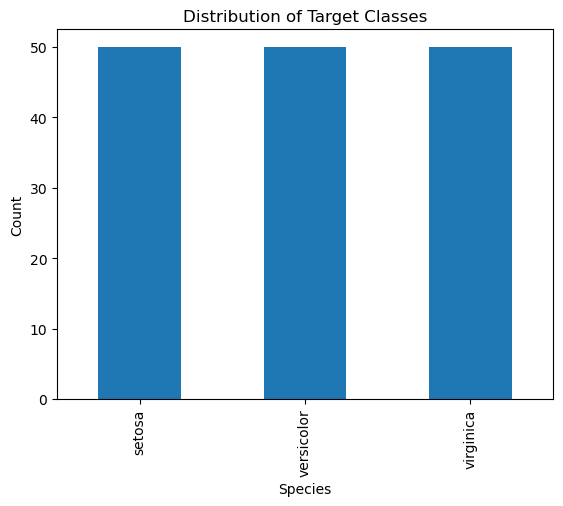

In [4]:
data['species'].value_counts().plot(kind='bar')
plt.title("Distribution of Target Classes")
plt.xlabel("Species")
plt.ylabel("Count")
plt.show()

## Feature Selection

In [5]:
features = data.iloc[:, :-1]
target = data.iloc[:, -1]

## Data Splitting

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.25, stratify=target, random_state=1
)

## Building Decision Tree Model

In [7]:
model = DecisionTreeClassifier(
    max_depth=3,   
    random_state=1
)

model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=1)

## Prediction

In [8]:
predictions = model.predict(X_test)

## Model Performance

In [9]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.93      1.00      0.96        13
   virginica       1.00      0.92      0.96        13

    accuracy                           0.97        38
   macro avg       0.98      0.97      0.97        38
weighted avg       0.98      0.97      0.97        38



## Confusion Matrix

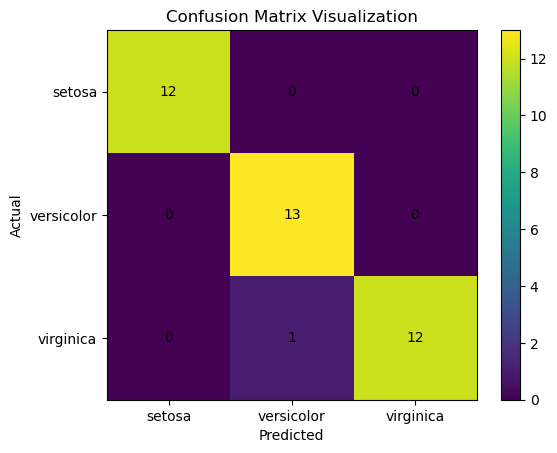

In [10]:
cm = confusion_matrix(y_test, predictions)

plt.imshow(cm)
plt.title("Confusion Matrix Visualization")
plt.colorbar()

plt.xticks(range(3), target.unique())
plt.yticks(range(3), target.unique())

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Tree Visualization

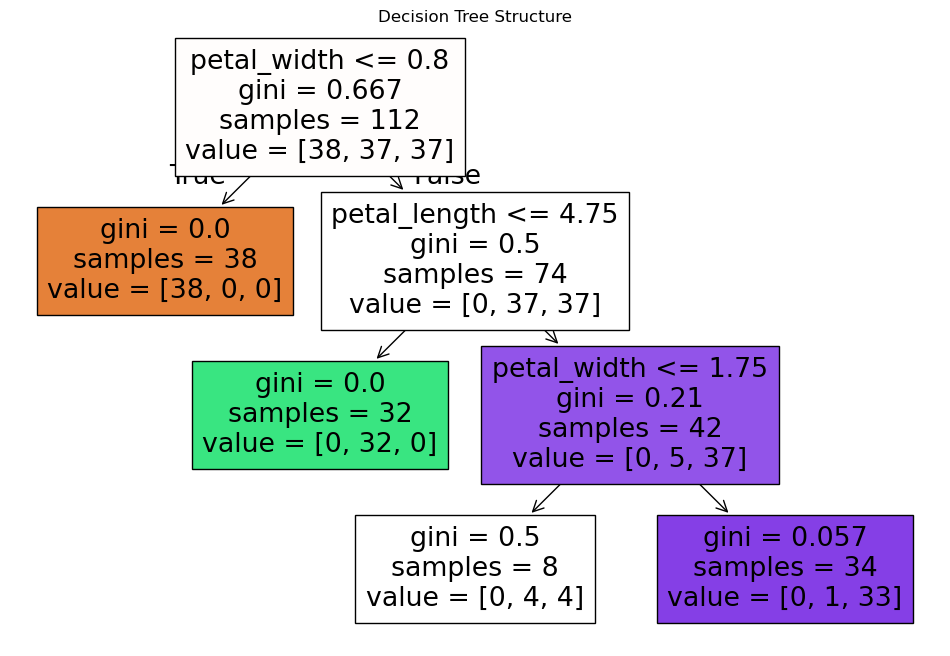

In [11]:
from sklearn.tree import plot_tree

plt.figure(figsize=(12,8))
plot_tree(model, filled=True, feature_names=features.columns)
plt.title("Decision Tree Structure")
plt.show()

## Feature Contribution Analysis

In [12]:
importance = model.feature_importances_

for f, val in zip(features.columns, importance):
    print(f"{f} → {round(val, 3)}")

sepal_length → 0.0
sepal_width → 0.0
petal_length → 0.41
petal_width → 0.59


## Accuracy Check

In [13]:
from sklearn.metrics import accuracy_score

print("Model Accuracy:", accuracy_score(y_test, predictions))

Model Accuracy: 0.9736842105263158


## Conclusion

- Decision Trees provide intuitive and interpretable models
- Pre-pruning helps control complexity
- Model performs well on structured datasets like Iris

---

## Key Highlight

This implementation uses:

1.Stratified splitting  
2.Pre-pruning instead of post-pruning  
3.Clean visualization  
4.Interpretability-focused approach  
